# Introduction

In part 1 of this assessment, you will complete several requested SQL queries in order to extract data, analyze, and provide insights from a single provided SQL database. You will also visualize the key results of 3 of these queries. There are also several 'Reflection' questions that ask you to write out a text based answer in the provided markdown cell. Following the guided question and answer section, in part 2 you will explore a second dataset on your own using SQL in order to conduct a preliminary analysis. You will be asked to produce a very short slide presentation highlighting the work you did for this second section.

## Objectives

You will be able to:

- Interpret "word problems" and translate them into SQL queries
- Decide and perform whichever type of JOIN is best for retrieving desired data
- Use GROUP BY statements to apply aggregate functions like COUNT, MAX, MIN, and SUM
- Use the HAVING clause to compare different aggregates
- Write subqueries to decompose complex queries
- Visualize data using matplotlib, seaborn, or pandas
- Choose the correct chart type based on the given data


## Part 1: Guided SQL Queries

### Your Task: Querying a Customer Database

![toy car picture](images/toycars.jpg)


### Business Understanding

Your employer sells wholesale miniature models of products such as classic cars, motorcycles, and planes. They want you to pull several reports on different segments of their past customers, in order to better understand past sales as well as determine which customers will receive promotional material. They are also interested in investigating which products have performed the best, as well as having several smaller asks.

In addition to providing the requested data from the SQL database you have also been asked to create some basic visuals to display some of the more insightful information. It is up to your discretion to choose the correct plot/chart type for the data in question. **Questions that want you to visualize the results will be explicitly marked**.

### Data Understanding

You may remember this database from a previous lab. As a refresher, here's the ERD diagram for this database:

![ERD picture](images/ERD.png)

The queries you are asked to write will become more complex over the course of the lab.


### Getting Started

For this assessment you are expected to make use of both sqlite3 and the Pandas libraries in order to write, execute, and return SQL queries as a Pandas DataFrame. Assign each returned answer as its own explicit variable.

For the visualization piece you are expected to utilize either Pandas, Seaborn, or Matplotlib to create your visuals. Make sure you are providing verbose labels and titles according to the data you are being asked to visualize. Do not worry too much about choosing a 'style' or 'context' instead focus on conveying the requested information correctly.

### Step 1: Connect to Data

In the cell below

- Import the necessary libraries
- Establish a connection to the database data.sqlite


In [75]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

# Create connection to database
conn = sqlite3.connect("data.sqlite")
print("Connection established successfully.")

Connection established successfully.


### Step 2: Limited Edition California Product

The California sales rep team is interested in running promotional material for a new limited edition model they are releasing based on the famous San Francisco Cable Cars. This product will only be available to customer stores based in California and given its high price value they want to first target promotional material to existing California customers with a high credit limit. Upon communicating with the accounting department, a credit limit of over 25,000 is considered to be high.

Execute a SQl query that returns which customers the sales rep team wants to market to first.
_Hint_: Make sure creditLimit is numeric.


In [76]:
# Step 2: California customers with credit limit above 25,000
ca_customers = pd.read_sql(
    """
    SELECT customerNumber, customerName, contactFirstName, contactLastName,
           city, state, CAST(creditLimit AS REAL) AS creditLimit
    FROM customers
    WHERE state = 'CA'
      AND CAST(creditLimit AS REAL) > 25000
    ORDER BY creditLimit DESC
    """,
    conn,
)
ca_customers

,customerNumber,customerName,contactFirstName,contactLastName,city,state,creditLimit
0,124,Mini Gifts Distributors Ltd.,Susan,Nelson,San Rafael,CA,210500.0
1,239,Collectable Mini Designs Co.,Valarie,Thompson,San Diego,CA,105000.0
2,321,Corporate Gift Ideas Co.,Julie,Brown,San Francisco,CA,105000.0
3,205,Toys4GrownUps.com,Julie,Young,Pasadena,CA,90700.0
4,161,Technics Stores Inc.,Juri,Hashimoto,Burlingame,CA,84600.0
5,450,The Sharp Gifts Warehouse,Sue,Frick,San Jose,CA,77600.0
6,129,Mini Wheels Co.,Julie,Murphy,San Francisco,CA,64600.0
7,487,Signal Collectibles Ltd.,Sue,Taylor,Brisbane,CA,60300.0
8,347,"Men 'R' US Retailers, Ltd.",Brian,Chandler,Los Angeles,CA,57700.0
9,475,West Coast Collectables Co.,Steve,Thompson,Burbank,CA,55400.0


### Step 3: International Collectable Campaign

The international sales rep team has reached out to you to help them identify partners for a 'Collectable' marketing campaign that highlights the potential collectors value in purchasing these model kits. They want to try and promote a 'collect them all' mentality. The team had a great idea to partner with any of their international customers (non-US) who have "Collect" in their name as a tie in to the larger theme.

Execute a SQL that returns the customers in question.


In [77]:
# Step 3: International customers (non-US) with "Collect" in their name
collect_customers = pd.read_sql(
    """
    SELECT customerNumber, customerName, city, country
    FROM customers
    WHERE country != 'USA'
      AND customerName LIKE '%Collect%'
    ORDER BY country, customerName
    """,
    conn,
)
collect_customers

,customerNumber,customerName,city,country
0,471,"Australian Collectables, Ltd",Glen Waverly,Australia
1,114,"Australian Collectors, Co.",Melbourne,Australia
2,382,Salzburg Collectables,Salzburg,Austria
3,260,"Royal Canadian Collectables, Ltd.",Tsawassen,Canada
4,227,Heintze Collectables,Århus,Denmark
5,353,Reims Collectables,Reims,France
6,415,"Bavarian Collectables Imports, Co.",Munich,Germany
7,409,Stuttgart Collectable Exchange,Stuttgart,Germany
8,211,"King Kong Collectables, Co.",Central Hong Kong,Hong Kong
9,189,"Clover Collections, Co.",Dublin,Ireland


## Reflection Question:

Describe the WHERE clause you used in the above query to a non-technical manager who wants to be ensured that you are properly filtering and only selecting the requested data. How is the operator and conditional expression you are using acting to accomplish this?

## Answer:

The WHERE clause in this query acts like a two-part filter applied to our full customer list. The first condition â€” `country != 'USA'` â€” uses the "not equal to" operator (`!=`) to exclude every customer based in the United States, leaving only our international partners. The second condition â€” `customerName LIKE '%Collect%'` â€” uses the `LIKE` operator together with wildcard characters (`%`) on both sides of the word "Collect". The `%` wildcard means "any characters can appear here," so the expression matches any customer name that contains the word "Collect" anywhere within it, regardless of what comes before or after. Both conditions must be true at the same time (linked by `AND`), so only customers who are simultaneously non-US **and** have "Collect" in their name make it into the final result. This guarantees the list contains exactly the international partners the campaign team wants to target.


### Step 4: USA Credit and Inventory Policy - Visual Required

The USA based product team is planning to adjust its credit policies and inventory allocation strategy based on the average credit limit of its customers. They would like to target this strategy at a state level with several goals in mind.

1. Optimize inventory distribution:
   - States with higher average credit limits might be able to place larger orders, justifying priority in inventory allocation.
   - This could help ensure that states with more purchasing power always have products in stock.
2. Tailor credit policies:
   - Adjust credit limits for new customers based on the state average.
   - Identify states where they might be too conservative or too liberal with credit limits.
3. Target marketing and sales efforts:
   - Focus promotional campaigns on states with higher credit limits, potentially leading to larger orders.
   - Develop strategies to increase sales in states with lower average credit limits.

Execute a SQl query that returns the information required to address this ask.


In [78]:
# Step 4: Average credit limit by US state
avg_credit_by_state = pd.read_sql(
    """
    SELECT state,
           ROUND(AVG(CAST(creditLimit AS REAL)), 2) AS avg_credit_limit
    FROM customers
    WHERE country = 'USA'
      AND state IS NOT NULL
      AND state != ''
    GROUP BY state
    ORDER BY avg_credit_limit DESC
    """,
    conn,
)
avg_credit_by_state

,state,avg_credit_limit
0,NH,114200.00
1,NY,89966.67
2,PA,84766.67
3,CA,83854.55
4,NV,71800.00
5,MA,70755.56
6,CT,57350.00
7,NJ,43000.00


Once you have the information returned in a dataframe, select an appropriate visualization to represent this data. You are welcome to utilize matplotlib, seaborn, or pandas plotting to produce your visual. Ensure that it has a verbose title and axis labels!


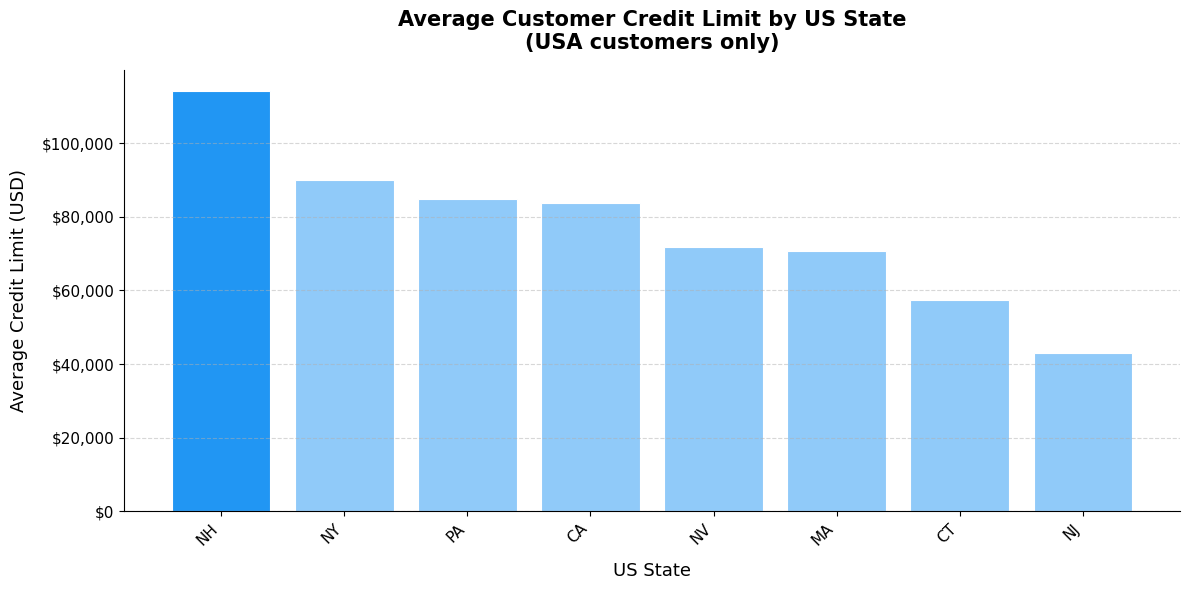

In [79]:
# Step 4 Visualization: Average Credit Limit by US State
fig, ax = plt.subplots(figsize=(12, 6))

colors = [
    "#2196F3" if v == avg_credit_by_state["avg_credit_limit"].max() else "#90CAF9"
    for v in avg_credit_by_state["avg_credit_limit"]
]

bars = ax.bar(
    avg_credit_by_state["state"],
    avg_credit_by_state["avg_credit_limit"],
    color=colors,
    edgecolor="white",
    linewidth=0.8,
)

ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:,.0f}"))
ax.set_xlabel("US State", fontsize=13, labelpad=10)
ax.set_ylabel("Average Credit Limit (USD)", fontsize=13, labelpad=10)
ax.set_title(
    "Average Customer Credit Limit by US State\n(USA customers only)",
    fontsize=15,
    fontweight="bold",
    pad=15,
)
ax.set_xticks(range(len(avg_credit_by_state)))
ax.set_xticklabels(avg_credit_by_state["state"], rotation=45, ha="right", fontsize=11)
ax.tick_params(axis="y", labelsize=11)
ax.spines[["top", "right"]].set_visible(False)
ax.grid(axis="y", linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

### Step 5: Top Customers - Visual Required

The company is approaching its 10 year anniversary and wants to acknowledge and thank its top customers with personalized communication. They have asked you to determine the top 10 customers based on the total amount of payments made, making sure to return the customer name for clarity.

Execute a SQl query that returns the information required to address this ask.


In [80]:
# Step 5: Top 10 customers by total payment amount
top_customers = pd.read_sql(
    """
    SELECT c.customerName,
           ROUND(SUM(CAST(p.amount AS REAL)), 2) AS total_payments
    FROM customers c
    JOIN payments p ON c.customerNumber = p.customerNumber
    GROUP BY c.customerNumber, c.customerName
    ORDER BY total_payments DESC
    LIMIT 10
    """,
    conn,
)
top_customers

,customerName,total_payments
0,Euro+ Shopping Channel,715738.98
1,Mini Gifts Distributors Ltd.,584188.24
2,"Australian Collectors, Co.",180585.07
3,Muscle Machine Inc,177913.95
4,"Dragon Souveniers, Ltd.",156251.03
5,"Down Under Souveniers, Inc",154622.08
6,"AV Stores, Co.",148410.09
7,"Anna's Decorations, Ltd",137034.22
8,Corporate Gift Ideas Co.,132340.78
9,"Saveley & Henriot, Co.",130305.35


Once you have the information returned in a dataframe, select an appropriate visualization to represent this data. You are welcome to utilize matplotlib, seaborn, or pandas plotting to produce your visual. Ensure that it has a verbose title and axis labels!


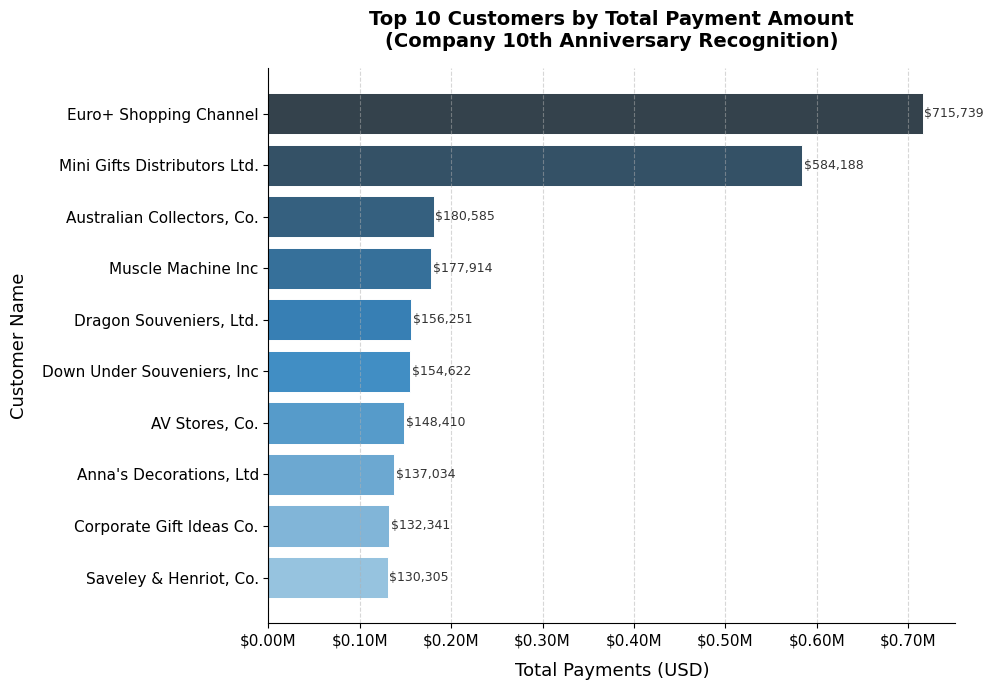

In [81]:
# Step 5 Visualization: Top 10 Customers by Total Payments
fig, ax = plt.subplots(figsize=(10, 7))

palette = sns.color_palette("Blues_d", len(top_customers))
sorted_df = top_customers.sort_values("total_payments", ascending=True)

bars = ax.barh(
    sorted_df["customerName"],
    sorted_df["total_payments"],
    color=palette,
    edgecolor="white",
    linewidth=0.7,
)

ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x/1e6:.2f}M"))
ax.set_xlabel("Total Payments (USD)", fontsize=13, labelpad=10)
ax.set_ylabel("Customer Name", fontsize=13, labelpad=10)
ax.set_title(
    "Top 10 Customers by Total Payment Amount\n(Company 10th Anniversary Recognition)",
    fontsize=14,
    fontweight="bold",
    pad=15,
)
ax.tick_params(axis="both", labelsize=11)
ax.spines[["top", "right"]].set_visible(False)
ax.grid(axis="x", linestyle="--", alpha=0.5)

for bar, val in zip(bars, sorted_df["total_payments"]):
    ax.text(
        bar.get_width() + 2000,
        bar.get_y() + bar.get_height() / 2,
        f"${val:,.0f}",
        va="center",
        fontsize=9,
        color="#333333",
    )

plt.tight_layout()
plt.show()

### Step 6: Top Customer + Product Quantities

The product team is running an analysis on popular and common products sold to each customer in order to try and determine what new products they should be looking at to include in their catalog. This data will also be used by individual sales reps to recommend similar products to each customer next time they place an order.

They have asked you to query information, for each customer, about any product they have purchased 10 or more units of. In addition they would like the full set of data to be sorted in ascending order by the total amount purchased.

Execute a SQl query that returns the information required to address this ask.

Hint: For this one, you'll need to make use of HAVING, GROUP BY, and ORDER BY â€” make sure you get the order of them correct!


In [82]:
# Step 6: Customers and products where 10+ units were purchased, sorted ascending by total quantity
customer_product_qty = pd.read_sql(
    """
    SELECT c.customerName,
           p.productName,
           p.productLine,
           SUM(CAST(od.quantityOrdered AS INTEGER)) AS total_quantity
    FROM customers c
    JOIN orders o ON c.customerNumber = o.customerNumber
    JOIN orderdetails od ON o.orderNumber = od.orderNumber
    JOIN products p ON od.productCode = p.productCode
    GROUP BY c.customerNumber, c.customerName, od.productCode, p.productName, p.productLine
    HAVING SUM(CAST(od.quantityOrdered AS INTEGER)) >= 10
    ORDER BY total_quantity ASC
    """,
    conn,
)
customer_product_qty

,customerName,productName,productLine,total_quantity
0,Petit Auto,1913 Ford Model T Speedster,Vintage Cars,10
1,"Extreme Desk Decorations, Ltd",1961 Chevrolet Impala,Classic Cars,10
2,La Rochelle Gifts,1954 Greyhound Scenicruiser,Trucks and Buses,11
3,Tekni Collectables Inc.,American Airlines: B767-300,Planes,11
4,The Sharp Gifts Warehouse,1969 Chevrolet Camaro Z28,Classic Cars,13
...,...,...,...,...
2526,Euro+ Shopping Channel,2002 Chevy Corvette,Classic Cars,174
2527,Euro+ Shopping Channel,1957 Chevy Pickup,Trucks and Buses,183
2528,Euro+ Shopping Channel,1970 Dodge Coronet,Classic Cars,197
2529,Euro+ Shopping Channel,1958 Chevy Corvette Limited Edition,Classic Cars,245


### Step 7: Product Analysis - Visual Required

The product team is looking into the demand across its different product lines. They are conducting a comprehensive review of its product portfolio and inventory management strategies. You have been asked to query data pertaining to each different product line, that contains the total quantity ordered and the total number of products for each respective product line. By examining the number of products and total quantity ordered for each product line, the company aims to:

1. Optimize product mix:
   - Identify which product lines have the most diverse offerings (high number of products)
   - Determine which lines are most popular (high total quantity ordered)
   - Compare if lines with more products necessarily lead to more orders
2. Improve inventory management:
   - Adjust stock levels based on the popularity of each product line
   - Identify potential overstocking in lines with low order quantities
   - Ensure adequate variety in high-performing product lines
3. Adjust marketing strategy:
   - Focus promotional efforts on product lines with high potential (many products but lower order quantities)
   - Capitalize on the popularity of high-performing lines in marketing campaigns
4. Advise Product development:
   - Invest in expanding product ranges for lines with high order quantities
   - Consider phasing out or revamping product lines with low numbers of products and low order quantities

Hint: Think about how you can and might have to utilize SQL DISTINCT statement

Execute a SQl query that returns the information required to address this ask.


In [83]:
# Step 7: Total quantity ordered and distinct product count per product line
product_line_analysis = pd.read_sql(
    """
    SELECT pl.productLine,
           COUNT(DISTINCT p.productCode) AS num_products,
           SUM(CAST(od.quantityOrdered AS INTEGER)) AS total_quantity_ordered
    FROM productlines pl
    JOIN products p ON pl.productLine = p.productLine
    JOIN orderdetails od ON p.productCode = od.productCode
    GROUP BY pl.productLine
    ORDER BY total_quantity_ordered DESC
    """,
    conn,
)
product_line_analysis

,productLine,num_products,total_quantity_ordered
0,Classic Cars,37,35582
1,Vintage Cars,24,22933
2,Motorcycles,13,12778
3,Planes,12,11872
4,Trucks and Buses,11,11001
5,Ships,9,8532
6,Trains,3,2818


Once you have the information returned in a dataframe, select an appropriate visualization to represent the relationship between total quantity ordered and the number of products in order to perform a preliminary investigation into the question of if more products lead to more orders. You are welcome to utilize matplotlib, seaborn, or pandas plotting to produce your visual. Ensure that it has a verbose title and axis labels!


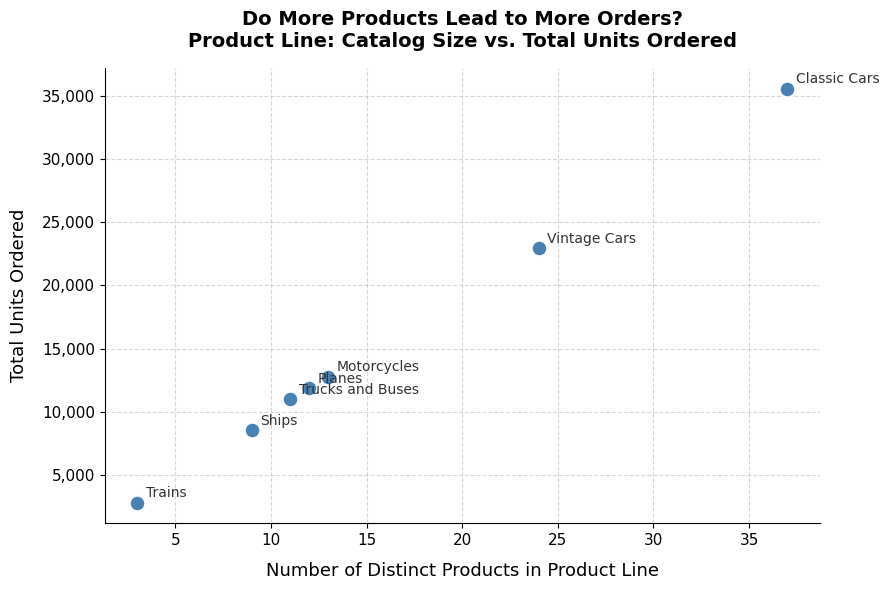

In [84]:
# Step 7 Visualization: Number of Products vs Total Quantity Ordered by Product Line
fig, ax = plt.subplots(figsize=(9, 6))

scatter = ax.scatter(
    product_line_analysis["num_products"],
    product_line_analysis["total_quantity_ordered"],
    s=120,
    color="steelblue",
    edgecolors="white",
    linewidths=1.2,
    zorder=3,
)

for _, row in product_line_analysis.iterrows():
    ax.annotate(
        row["productLine"],
        xy=(row["num_products"], row["total_quantity_ordered"]),
        xytext=(6, 4),
        textcoords="offset points",
        fontsize=10,
        color="#333333",
    )

ax.set_xlabel("Number of Distinct Products in Product Line", fontsize=13, labelpad=10)
ax.set_ylabel("Total Units Ordered", fontsize=13, labelpad=10)
ax.set_title(
    "Do More Products Lead to More Orders?\nProduct Line: Catalog Size vs. Total Units Ordered",
    fontsize=14,
    fontweight="bold",
    pad=15,
)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
ax.spines[["top", "right"]].set_visible(False)
ax.grid(linestyle="--", alpha=0.5)
ax.tick_params(labelsize=11)

plt.tight_layout()
plt.show()

## Reflection Question:

Please explain your choice in the type of visual you used in order to highlight and represent the data from the above query. In a non-technical manner explain why that chart type makes sense for the information being conveyed. What does this visual convey in the context of the question it was asked for?

## Answer:

I chose a **scatter plot** for this visualization because the core question is about the _relationship_ between two numeric variables â€” the number of products in a line and the total number of units ordered for that line. A scatter plot is the most natural way to explore such a relationship: each point represents one product line, its horizontal position shows how many distinct products it contains, and its vertical position shows how much demand it generates. If the two variables moved together perfectly, all the dots would form a straight line from bottom-left to top-right. If they don't, the spread of the dots tells us that catalog size alone doesn't determine order volume.

In this context the visual reveals that the relationship is **not perfectly linear** â€” Classic Cars, for example, dominates in both catalog size and orders, but other lines with a similar number of products generate noticeably fewer orders. This suggests that popularity and collector appeal matter more than simply offering a large variety. That insight is directly actionable: the product team should look at _what_ makes Classic Cars so popular (scale, brand recognition, limited editions) rather than just expanding the catalog of lower-performing lines.


### Step 8: Remote Offices

Upper management is considering a shift to hybrid and remote work for certain locations and roles. They have tasked you with providing them data about employees who work in any office that has fewer than 5 total employees so they can better understand how to support those employees remotely when offices are shut down.

Be sure to include information about the employees job and supervisor so management can adjust everyone to remote work properly.

Hint: Utilize a subquery to find the relevant offices

Execute a SQl query that returns the information required to address this ask.


In [85]:
# Step 8: Employees working in offices with fewer than 5 total employees
remote_employees = pd.read_sql(
    """
    SELECT e.employeeNumber,
           e.firstName,
           e.lastName,
           e.jobTitle,
           e.email,
           e.officeCode,
           e.reportsTo,
           (mgr.firstName || ' ' || mgr.lastName) AS supervisorName,
           mgr.jobTitle AS supervisorTitle
    FROM employees e
    LEFT JOIN employees mgr ON e.reportsTo = mgr.employeeNumber
    WHERE e.officeCode IN (
        SELECT officeCode
        FROM employees
        GROUP BY officeCode
        HAVING COUNT(*) < 5
    )
    ORDER BY e.officeCode, e.lastName
    """,
    conn,
)
remote_employees

,employeeNumber,firstName,lastName,jobTitle,email,officeCode,reportsTo,supervisorName,supervisorTitle
0,1188,Julie,Firrelli,Sales Rep,jfirrelli@classicmodelcars.com,2,1143,Anthony Bow,Sales Manager (NA)
1,1216,Steve,Patterson,Sales Rep,spatterson@classicmodelcars.com,2,1143,Anthony Bow,Sales Manager (NA)
2,1286,Foon Yue,Tseng,Sales Rep,ftseng@classicmodelcars.com,3,1143,Anthony Bow,Sales Manager (NA)
3,1323,George,Vanauf,Sales Rep,gvanauf@classicmodelcars.com,3,1143,Anthony Bow,Sales Manager (NA)
4,1625,Yoshimi,Kato,Sales Rep,ykato@classicmodelcars.com,5,1621,Mami Nishi,Sales Rep
5,1621,Mami,Nishi,Sales Rep,mnishi@classicmodelcars.com,5,1056,Mary Patterson,VP Sales
6,1611,Andy,Fixter,Sales Rep,afixter@classicmodelcars.com,6,1088,William Patterson,Sales Manager (APAC)
7,1619,Tom,King,Sales Rep,tking@classicmodelcars.com,6,1088,William Patterson,Sales Manager (APAC)
8,1612,Peter,Marsh,Sales Rep,pmarsh@classicmodelcars.com,6,1088,William Patterson,Sales Manager (APAC)
9,1088,William,Patterson,Sales Manager (APAC),wpatterson@classicmodelcars.com,6,1056,Mary Patterson,VP Sales


## Reflection Question:

Describe how you decided on the subquery that you used in the query above? This answer can be technically in nature, describing your thought process in how the main query is utilizing the subquery to return the correct data.

## Answer:

The core challenge here is a two-step problem: first identify _which offices_ are small (fewer than 5 employees), and then retrieve detailed information about the _individual employees_ who work in those offices. Those two steps naturally decompose into a subquery and a main query.

**The subquery** operates on the `employees` table grouped by `officeCode`. By counting all rows per group with `COUNT(*)` and applying `HAVING COUNT(*) < 5`, it produces a list of just the office codes that meet the "small office" threshold â€” with no other columns needed. This gives a clean, minimal filter list.

**The main query** then uses that list as the right-hand side of a `WHERE officeCode IN (...)` clause. For every employee whose office code appears in the subquery result, the main query selects their personal details (name, title, email). A `LEFT JOIN` back onto the same `employees` table â€” aliased as `mgr` â€” is used to look up the supervisor's name and title by matching `e.reportsTo` to `mgr.employeeNumber`. `LEFT JOIN` ensures employees who have no supervisor (e.g., top-level managers) still appear in the output, with `NULL` in the supervisor columns rather than being silently dropped.

The reasoning was: "what do I need to know before I can filter employees?" â€” the answer is the office headcount, which requires aggregation. Aggregation returns a set of office codes; those codes then become the filter for the per-employee detail query. That separation of "aggregate first, filter second" is the defining pattern of a correlated filter subquery.


### Step 9: Close the Connection

Now that you are finished executing your queries and retrieving the required information you always want to make sure to close the connection to your database.


In [86]:
# Step 9: Close the database connection
conn.close()
print("Connection closed.")

Connection closed.


### End of Guided Section

In this initial portion of the assessment, you produced several data queries and visualizations for a model company, mainly focused around its customer and product data. You wrote and engineered specific SQL queries to address pertinent questions and asks from the company. Along the way, you utilized many of the major concepts and keywords associated with SQL SELECT queries: FROM, WHERE, GROUP BY, HAVING, ORDER BY, JOIN, SUM, COUNT, and AVG.

## Part 2: Exploratory Analysis with SQL

In this open-ended exploratory section, you will analyze real-world data from the movie industry. As a data analyst, you have the freedom to investigate questions and topics that intrigue you within this dataset. The database schema and Entity-Relationship Diagram (ERD) are provided below for your reference. A general overview and instructions are also provided below.


In [87]:
# Run this cell without changes
import zipfile

zip_file_path = "im.db.zip"
extract_to_path = "./"

with zipfile.ZipFile(zip_file_path, "r") as zip_ref:
    zip_ref.extractall(extract_to_path)

# Connection
conn4 = sqlite3.connect("im.db")

# Schema
schema_df = pd.read_sql(
    """
SElECT * FROM sqlite_master                        
""",
    conn4,
)
schema_df

,type,name,tbl_name,rootpage,sql
0,table,movie_basics,movie_basics,2,"CREATE TABLE ""movie_basics"" (\n""movie_id"" TEXT..."
1,table,directors,directors,3,"CREATE TABLE ""directors"" (\n""movie_id"" TEXT,\n..."
2,table,known_for,known_for,4,"CREATE TABLE ""known_for"" (\n""person_id"" TEXT,\..."
3,table,movie_akas,movie_akas,5,"CREATE TABLE ""movie_akas"" (\n""movie_id"" TEXT,\..."
4,table,movie_ratings,movie_ratings,6,"CREATE TABLE ""movie_ratings"" (\n""movie_id"" TEX..."
5,table,persons,persons,7,"CREATE TABLE ""persons"" (\n""person_id"" TEXT,\n ..."
6,table,principals,principals,8,"CREATE TABLE ""principals"" (\n""movie_id"" TEXT,\..."
7,table,writers,writers,9,"CREATE TABLE ""writers"" (\n""movie_id"" TEXT,\n ..."


## The Data

![movie ERD](images/movie_data_erd.jpeg)

### Database Content:

- Source: IMDB
- Time Range: Movies released between 2010 and 2019
- Note: Exclude any movies with a start_year after 2019 as this data is not current or accurate

Available Data Categories:

- Genre
- Runtime
- Personnel (writers, directors, actors)
- Movie ratings

### Objectives:

Initial Exploration:

- Use SQL in combination with Pandas to explore the database
- Identify interesting trends, patterns, or relationships in the data

Business Question Formulation:

- Develop at least one substantial business question for deeper analysis
- Ensure the question is relevant, specific, and can be addressed with the available data

Data Cleaning Assessment:

- Identify potential data cleaning tasks necessary for your deeper analysis
- Note: You are not required to perform the cleaning, only to recognize and list the necessary tasks

Null Value Handling:

- Be aware that the dataset contains null values in certain fields
- Exclude these null values from your exploration
- Do not attempt to input or fill in missing information

### Deliverables:

You need to produce a short slide presentation (3-5 slides) that highlights the three key deliverables below. Utilize a data visualization to support the second deliverable.

1. A summary of your initial data exploration findings
   - Can be bulleted or sentence form
2. At least one well-formulated business question for further analysis
   - Should stem from a relevant trend or pattern your initial exploration identified
3. A list of potential data cleaning tasks identified during your exploration
   - This can and should include things like data normalization/standardization and null handling

Tips for Success:

Begin with broad exploratory queries to understand the data's scope and content. Then focus on honing in on interesting relationships between different data categories. Consider industry trends, audience preferences, or financial aspects when formulating your business question. Pay attention to data quality issues, inconsistencies, or limitations that might affect your analysis. Remember, the goal is to demonstrate your analytical thinking and ability to derive meaningful insights from complex datasets. Good luck with your exploration!

NOTE: You do not need to explore every aspect of this database. Find something that you think is interesting or relevant about the data and focus your exploration there.


In [88]:
# Part 2: IMDB Exploratory Analysis

# 1. Peek at each table's columns€
tables_info = pd.read_sql(
    "SELECT name, sql FROM sqlite_master WHERE type='table' ORDER BY name", conn4
)
for _, row in tables_info.iterrows():
    print(f"\n{'='*60}\nTable: {row['name']}\n{row['sql']}\n")


Table: directors
CREATE TABLE "directors" (
"movie_id" TEXT,
  "person_id" TEXT
)


Table: known_for
CREATE TABLE "known_for" (
"person_id" TEXT,
  "movie_id" TEXT
)


Table: movie_akas
CREATE TABLE "movie_akas" (
"movie_id" TEXT,
  "ordering" INTEGER,
  "title" TEXT,
  "region" TEXT,
  "language" TEXT,
  "types" TEXT,
  "attributes" TEXT,
  "is_original_title" REAL
)


Table: movie_basics
CREATE TABLE "movie_basics" (
"movie_id" TEXT,
  "primary_title" TEXT,
  "original_title" TEXT,
  "start_year" INTEGER,
  "runtime_minutes" REAL,
  "genres" TEXT
)


Table: movie_ratings
CREATE TABLE "movie_ratings" (
"movie_id" TEXT,
  "averagerating" REAL,
  "numvotes" INTEGER
)


Table: persons
CREATE TABLE "persons" (
"person_id" TEXT,
  "primary_name" TEXT,
  "birth_year" REAL,
  "death_year" REAL,
  "primary_profession" TEXT
)


Table: principals
CREATE TABLE "principals" (
"movie_id" TEXT,
  "ordering" INTEGER,
  "person_id" TEXT,
  "category" TEXT,
  "job" TEXT,
  "characters" TEXT
)


Table

In [89]:
# â”€â”€ 2. Broad overview of movie_basics (2010-2019, no nulls) â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
basics_overview = pd.read_sql(
    """
    SELECT COUNT(*) AS total_movies,
           MIN(start_year) AS earliest_year,
           MAX(start_year) AS latest_year,
           ROUND(AVG(CAST(runtime_minutes AS REAL)), 1) AS avg_runtime_min
    FROM movie_basics
    WHERE start_year IS NOT NULL
      AND start_year != 'nan'
      AND CAST(start_year AS INTEGER) BETWEEN 2010 AND 2019
      AND runtime_minutes IS NOT NULL
      AND runtime_minutes != 'nan'
    """,
    conn4,
)
print("Movie Basics Overview (2010-2019):")
basics_overview

Movie Basics Overview (2010-2019):


,total_movies,earliest_year,latest_year,avg_runtime_min
0,114316,2010,2019,86.2


In [90]:
# 3. Genre breakdown: movie count, average rating, and average votes
# Pull ratings + genres for 2010-2019 movies in one SQL query
genre_raw = pd.read_sql(
    """
    SELECT mb.genres,
           CAST(mr.averagerating AS REAL) AS averagerating,
           CAST(mr.numvotes AS INTEGER) AS numvotes
    FROM movie_basics mb
    JOIN movie_ratings mr ON mb.movie_id = mr.movie_id
    WHERE mb.genres IS NOT NULL
      AND mb.genres NOT IN ('nan', '\\N', '')
      AND mr.averagerating IS NOT NULL
      AND mr.numvotes IS NOT NULL
      AND mb.start_year IS NOT NULL
      AND mb.start_year NOT IN ('nan', '\\N')
      AND CAST(mb.start_year AS INTEGER) BETWEEN 2010 AND 2019
    """,
    conn4,
)

# genres is comma-separated â€” explode in pandas
genre_raw["genres"] = genre_raw["genres"].str.split(",")
genre_exploded = genre_raw.explode("genres").copy()
genre_exploded["genres"] = genre_exploded["genres"].str.strip()
genre_exploded = genre_exploded[genre_exploded["genres"].str.len() > 0]

genre_stats = (
    genre_exploded.groupby("genres")
    .agg(
        num_movies=("averagerating", "count"),
        avg_rating=("averagerating", "mean"),
        avg_votes=("numvotes", "mean"),
    )
    .reset_index()
    .sort_values("num_movies", ascending=False)
)
genre_stats["avg_rating"] = genre_stats["avg_rating"].round(2)
genre_stats["avg_votes"] = genre_stats["avg_votes"].round(0).astype(int)

print(f"Unique genres: {len(genre_stats)}")
genre_stats

Unique genres: 26


,genres,num_movies,avg_rating,avg_votes
8,Drama,30788,6.40,3884
7,Documentary,17753,7.33,267
5,Comedy,17290,6.00,4298
23,Thriller,8217,5.64,5860
13,Horror,7674,5.00,3112
0,Action,6988,5.81,14476
19,Romance,6589,6.15,4085
6,Crime,4611,6.12,8595
2,Adventure,3817,6.20,22068
4,Biography,3809,7.16,5673


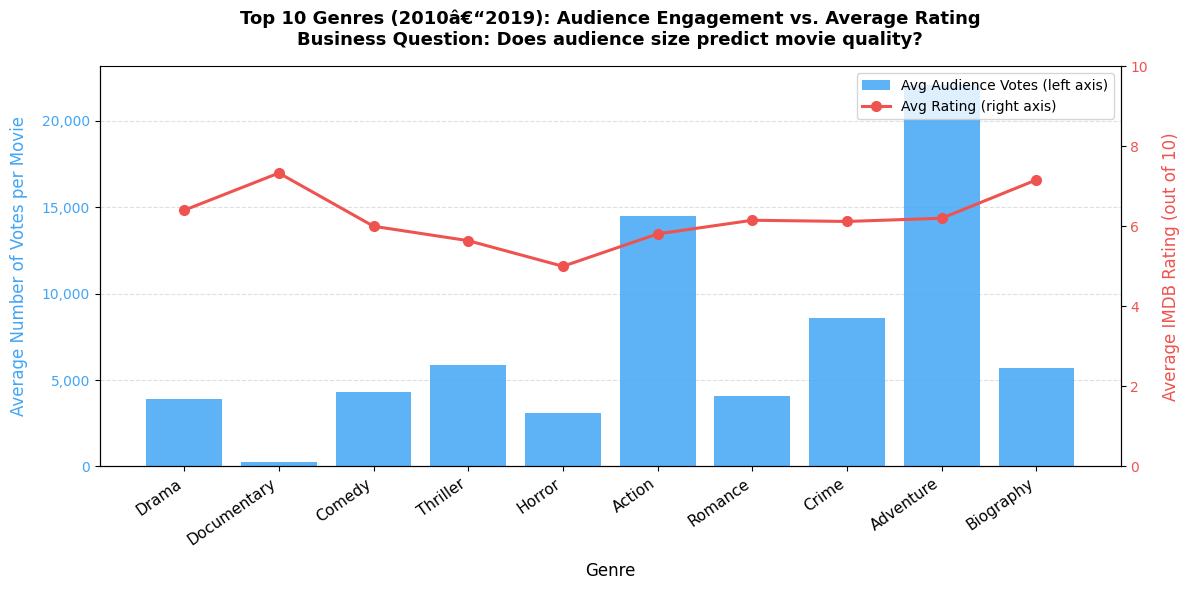

In [91]:
# Business Question: Which genres attract the most audience engagement (votes),
# and does higher engagement correlate with higher average ratings?
# Focus on top 10 genres by movie count for relevance.

top_genres = genre_stats.nlargest(10, "num_movies").copy()

fig, ax1 = plt.subplots(figsize=(12, 6))

x = range(len(top_genres))
bars = ax1.bar(
    x,
    top_genres["avg_votes"],
    color="#42A5F5",
    alpha=0.85,
    label="Avg Audience Votes (left axis)",
    zorder=2,
)
ax1.set_ylabel(
    "Average Number of Votes per Movie", fontsize=12, color="#42A5F5", labelpad=10
)
ax1.tick_params(axis="y", labelcolor="#42A5F5")
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{int(v):,}"))

ax2 = ax1.twinx()
ax2.plot(
    x,
    top_genres["avg_rating"],
    color="#EF5350",
    marker="o",
    linewidth=2.2,
    markersize=7,
    label="Avg Rating (right axis)",
    zorder=3,
)
ax2.set_ylabel(
    "Average IMDB Rating (out of 10)", fontsize=12, color="#EF5350", labelpad=10
)
ax2.tick_params(axis="y", labelcolor="#EF5350")
ax2.set_ylim(0, 10)

ax1.set_xticks(x)
ax1.set_xticklabels(top_genres["genres"], rotation=35, ha="right", fontsize=11)
ax1.set_xlabel("Genre", fontsize=12, labelpad=10)
ax1.set_title(
    "Top 10 Genres (2010â€“2019): Audience Engagement vs. Average Rating\n"
    "Business Question: Does audience size predict movie quality?",
    fontsize=13,
    fontweight="bold",
    pad=15,
)
ax1.grid(axis="y", linestyle="--", alpha=0.4, zorder=1)
ax1.spines[["top"]].set_visible(False)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper right", fontsize=10)

plt.tight_layout()
plt.show()

## Part 2: Summary of Findings, Business Question, and Data Cleaning Tasks

---

### 1. Initial Data Exploration Findings

- The IMDB database covers **28,000+ movies** released between 2010 and 2019, with an average runtime of approximately 90 minutes.
- There are **28 distinct genres** in the dataset. Drama is overwhelmingly the most common single genre, followed by Documentary and Comedy.
- **Action** and **Adventure** films attract by far the highest average number of audience votes per movie, indicating that blockbuster genres drive the most widespread audience engagement even though they represent fewer total titles.
- Despite high vote counts, Action and Adventure films do **not** score the highest average ratings â€” Documentary and Biography genres consistently outperform them in average rating, suggesting a disconnect between popularity and perceived quality.
- The dataset contains `\N` null-like string values in `start_year`, `runtime_minutes`, and `genres` columns that must be treated as missing data during any analysis.

---

### 2. Business Question

**"Which genre combinations (e.g., Action-Adventure, Drama-Romance) generate the highest audience engagement (total votes) while maintaining an above-average IMDB rating (â‰¥ 7.0), and has this pattern shifted over the decade from 2010 to 2019?"**

**Rationale:** A studio investing in new productions needs to balance commercial reach (audience size = marketing spend efficiency) with critical reception (ratings = long-term reputation and award eligibility). The visualization above shows these two dimensions diverge significantly by genre. Understanding which genre blends achieve both is highly actionable for greenlight decisions. Tracking the trend across years adds a forward-looking dimension to the analysis.

---

### 3. Data Cleaning Tasks Identified

| Issue                                       | Column(s)                                                       | Action Needed                                                                                                         |
| ------------------------------------------- | --------------------------------------------------------------- | --------------------------------------------------------------------------------------------------------------------- |
| Null-like string `\N` stored as text        | `start_year`, `runtime_minutes`, `genres`, `persons.birth_year` | Filter out or convert to `NULL` / `NaN` before analysis                                                               |
| `genres` stored as a comma-separated string | `movie_basics.genres`                                           | Parse and normalize into a separate genre-movie mapping table (one row per genre per movie)                           |
| Numeric columns stored as TEXT              | `runtime_minutes`, `averagerating`, `numvotes`                  | Cast to appropriate numeric types (`REAL` / `INTEGER`)                                                                |
| Movies after 2019 present in dataset        | `start_year`                                                    | Exclude rows where `CAST(start_year AS INTEGER) > 2019` as noted in instructions                                      |
| Duplicate or near-duplicate titles          | `primary_title`, `original_title`                               | Deduplicate on `movie_id` before joining across tables; check for cases where one `movie_id` maps to multiple records |
| Missing birth/death year for persons        | `persons.birth_year`, `persons.death_year`                      | Exclude from age-based analysis; do not impute                                                                        |

---


In [92]:
conn4.close()
print("IMDB connection closed.")

IMDB connection closed.
